In [1]:
import fdfi
print(fdfi.__version__)

0.0.5


In [3]:
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from fdfi.explainers import FlowExplainer, Crossfitting

## Load Data And Feature Groups


In [4]:
DATA_DIR = Path("data")

DATASETS = {
    "sens50": {
        "file": DATA_DIR / "sens50_processed_dataset.csv",
        "target": "sens50",
    },
    "sens80": {
        "file": DATA_DIR / "sens80_processed_dataset.csv",
        "target": "sens80",
    },
    "ic50": {
        "file": DATA_DIR / "ic50.censored_processed_dataset.csv",
        "target": "ic50.censored",
    },
}

outcome = "sens50"

cfg = DATASETS[outcome]
filename = str(cfg["file"])

data = pd.read_csv(cfg["file"])
y = data[cfg["target"]].astype(int)
X = data.drop(columns=[cfg["target"]])

df_groups = pd.read_csv(DATA_DIR / "feature_group.csv", index_col=0).set_index("feature")
df_groups = pd.get_dummies(df_groups["group"]).groupby(df_groups.index).max().reindex(X.columns)

print(f"Dataset shape: {X.shape}")
print(f"Target variable: {outcome}")
print(f"Number of groups: {len(df_groups.columns)}")
print(f"Data loaded from: {filename}")


Dataset shape: (611, 832)
Target variable: sens50
Number of groups: 14
Data loaded from: data/sens50_processed_dataset.csv


In [5]:
print("Data preparation...")

preprocess = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    StandardScaler(),
)

X_values = preprocess.fit_transform(X)
y_values = y.values

print("Data preparation finished")
print(f"Feature matrix shape: {X_values.shape}")
print(f"Target vector shape: {y_values.shape}")
print(f"Target statistics: mean={y_values.mean():.3f}, std={y_values.std():.3f}")
print(f"Missing values - X: {np.isnan(X_values).sum()}, y: {np.isnan(y_values).sum()}")
print("After standardization:")
print(f"X mean: {X_values.mean():.3f}, std: {X_values.std():.3f}")


Data preparation...
Data preparation finished
Feature matrix shape: (611, 832)
Target vector shape: (611,)
Target statistics: mean=0.615, std=0.487
Missing values - X: 0, y: 0
After standardization:
X mean: -0.000, std: 1.000


In [6]:
clf = LogisticRegression(
    penalty="l1",
    solver="saga",
    C=1.0,
    max_iter=5000,
    class_weight="balanced",
    random_state=42,
)

clf.fit(X_values, y_values)

model_fn = lambda X_: clf.predict_proba(X_)[:, 1]

pred = model_fn(X_values)

print("Model trained")
print("Prediction mean:", pred.mean())
print("Nonzero coefficients:", np.sum(np.abs(clf.coef_.ravel()) > 1e-12))


Model trained
Prediction mean: 0.6075057118529973
Nonzero coefficients: 336


## Fit Flowmatching FDFI


In [7]:
print("Fitting FlowMatching FDFI with 5-fold cross fitting...")

n_folds = 5
nsamples_main = 20
flow_num_steps = 200

start_time = time.time()

cv = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)

fdfi_estimator = Crossfitting(
    model=model_fn,
    data=X_values,
    explainer_class=FlowExplainer,
    cv=cv,
    y=y_values,
    nsamples=nsamples_main,
    method="cpi",
    sampling_method="resample",
    num_steps=flow_num_steps,
    random_state=42,
    verbose="final",
)

cf_results = fdfi_estimator()

dfi_time = time.time() - start_time

print(f"FlowMatching FDFI completed in {dfi_time:.2f} seconds")
print(f"DFI scores shape: {cf_results['phi_X'].shape}")

np.sum(cf_results["phi_X"]), np.sum(cf_results["phi_Z"])


Fitting FlowMatching FDFI with 5-fold cross fitting...
[FDFI][INFO] Training flow model...
Training complete: 200 steps, final loss=1.8753
[FDFI][DIAG] Flow Model Diagnostics
[FDFI][DIAG] Latent independence (median dCor): 0.108740 [MODERATE]  -> lower is better
[FDFI][DIAG] Distribution fidelity (MMD):       0.000001 [GOOD]  -> lower is better
[FDFI][INFO] Training flow model...
Training complete: 200 steps, final loss=1.7887
[FDFI][DIAG] Flow Model Diagnostics
[FDFI][DIAG] Latent independence (median dCor): 0.109339 [MODERATE]  -> lower is better
[FDFI][DIAG] Distribution fidelity (MMD):       0.000001 [GOOD]  -> lower is better
[FDFI][INFO] Training flow model...
Training complete: 200 steps, final loss=1.8448
[FDFI][DIAG] Flow Model Diagnostics
[FDFI][DIAG] Latent independence (median dCor): 0.109677 [MODERATE]  -> lower is better
[FDFI][DIAG] Distribution fidelity (MMD):       0.000002 [GOOD]  -> lower is better
[FDFI][INFO] Training flow model...
Training complete: 200 steps, fin

(np.float64(0.11143202105953441), np.float64(0.10426817900156266))

## Individual Feature Inference With conf_int()

In [8]:
# Individual feature-level inference from module-level conf_int().
# In v0.0.5, conf_int() returns "score" and "se".
# "se" is standard error, used for CI and hypothesis testing.

feature_names = X.columns.tolist()
n_features = len(feature_names)
alpha = 0.05

ci_X = fdfi_estimator.conf_int(
    alpha=0.05,
    target="X",
    var_floor_c=0.1,
    var_floor_method="mixture",
    var_floor_quantile=0.95,
    margin=0.0,
    margin_method="auto",
    margin_quantile=0.95,
    alternative="two-sided",
    verbose=False,
)

ci_Z = fdfi_estimator.conf_int(
    alpha=0.05,
    target="Z",
    var_floor_c=0.1,
    var_floor_method="mixture",
    var_floor_quantile=0.95,
    margin=0.0,
    margin_method="auto",
    margin_quantile=0.95,
    alternative="two-sided",
    verbose=False,
)

dfi = ci_X["score"]
dfi_se = ci_X["se"]
dfiz = ci_Z["score"]
dfiz_se = ci_Z["se"]

dfi_scores = dfi / np.maximum(dfi_se, 1e-12)
dfiz_scores = dfiz / np.maximum(dfiz_se, 1e-12)

dfi_p_values = ci_X["pvalue"]
dfiz_p_values = ci_Z["pvalue"]

dfi_order = np.argsort(dfi_scores)[::-1]
dfiz_order = np.argsort(dfiz_scores)[::-1]

dfi_rank = np.empty(n_features, dtype=int)
dfi_rank[dfi_order] = np.arange(1, n_features + 1)

dfiz_rank = np.empty(n_features, dtype=int)
dfiz_rank[dfiz_order] = np.arange(1, n_features + 1)

results = pd.DataFrame({
    "feature": feature_names,
    "dfi": dfi,
    "dfi_se": dfi_se,
    "dfi_zscore": dfi_scores,
    "dfi_p_value": dfi_p_values,
    "dfi_ci_lower": ci_X["ci_lower"],
    "dfi_ci_upper": ci_X["ci_upper"],
    "dfi_reject_null": ci_X["reject_null"],
    "dfi_ranking": dfi_rank,
    "dfiz": dfiz,
    "dfiz_se": dfiz_se,
    "dfiz_score": dfiz_scores,
    "dfiz_p_value": dfiz_p_values,
    "dfiz_ci_lower": ci_Z["ci_lower"],
    "dfiz_ci_upper": ci_Z["ci_upper"],
    "dfiz_reject_null": ci_Z["reject_null"],
    "dfiz_ranking": dfiz_rank,
})

OUT_DIR = Path("results") / "flowmatching_case_study"
OUT_DIR.mkdir(parents=True, exist_ok=True)
results.to_csv(OUT_DIR / f"{outcome}_flowmatching_dfi_results.csv", index=False)


## Feature-Level Summary

In [9]:
print("=== X-space feature summary ===")
_ = fdfi_estimator.summary(
    alpha=0.05,
    target="X",
    var_floor_c=0.1,
    var_floor_method="mixture",
    var_floor_quantile=0.95,
    margin=0.0,
    margin_method="auto",
    margin_quantile=0.95,
    alternative="two-sided",
)

print("\n=== Z-space feature summary ===")
_ = fdfi_estimator.summary(
    alpha=0.05,
    target="Z",
    var_floor_c=0.1,
    var_floor_method="mixture",
    var_floor_quantile=0.95,
    margin=0.0,
    margin_method="auto",
    margin_quantile=0.95,
    alternative="two-sided",
)

=== X-space feature summary ===
Feature Importance Results
Method: Crossfitting
Number of units: 832
Significance level: 0.05
Alternative: two-sided
Margin method: mixture
Practical margin: 0.0018
------------------------------------------------------------------------------
        Feature   Estimate    Std Err   CI Lower   CI Upper    P-value   Sig
------------------------------------------------------------------------------
              0     0.0000     0.0017    -0.0034     0.0034     0.2958      
              1     0.0009     0.0017    -0.0025     0.0043     0.5880      
              2     0.0000     0.0017    -0.0034     0.0034     0.2939      
              3     0.0000     0.0017    -0.0034     0.0034     0.2938      
              4     0.0000     0.0017    -0.0034     0.0034     0.2988      
              5     0.0011     0.0019    -0.0026     0.0048     0.6957      
              6     0.0001     0.0017    -0.0033     0.0035     0.3106      
              7     0.0000   

## Group Importance

In [10]:
group_ci = fdfi_estimator.conf_int(
    alpha=0.05,
    target="X",
    groups=df_groups,
    threshold_null=True,
    var_floor_c=0.1,
    var_floor_method="fixed",
    margin=0.0,
    margin_method="fixed",
    alternative="two-sided",
    multitest_method="bonferroni",
    verbose=False,
)

res_df = pd.DataFrame({
    "group": group_ci["groups"],
    "importance": group_ci["score"],
    "se": group_ci["se"],
    "ci_lower": group_ci["ci_lower"],
    "ci_upper": group_ci["ci_upper"],
    "p_value": group_ci["pvalue"],
    "p_value_adj": group_ci.get("pvalue_adj", group_ci["pvalue"]),
    "reject_null": group_ci["reject_null"],
})

res_df["zscore"] = res_df["importance"] / np.maximum(res_df["se"], 1e-12)


## Group Summary Table

In [11]:
print("=== X-space group summary ===")
_ = fdfi_estimator.summary(
    alpha=0.05,
    target="X",
    groups=df_groups,
    threshold_null=True,
    var_floor_c=0.1,
    var_floor_method="fixed",
    margin=0.0,
    margin_method="fixed",
    alternative="two-sided",
    multitest_method="bonferroni",
)
print("\n=== Z-space group summary ===")
_ = fdfi_estimator.summary(
    alpha=0.05,
    target="Z",
    groups=df_groups,
    threshold_null=True,
    var_floor_c=0.1,
    var_floor_method="fixed",
    margin=0.0,
    margin_method="fixed",
    alternative="two-sided",
    multitest_method="bonferroni",
)


=== X-space group summary ===
Feature Importance Results
Method: Crossfitting
Number of units: 14
Significance level: 0.05
Alternative: two-sided
Multiple testing: bonferroni
Margin method: fixed
------------------------------------------------------------------------------
          Group   Estimate    Std Err   CI Lower   CI Upper  Adj P-val   Sig
------------------------------------------------------------------------------
          cd4bs     0.0278     0.0053     0.0174     0.0382     0.0000   ***
          covar     0.0374     0.0059     0.0259     0.0489     0.0000   ***
      cysteines     0.0007     0.0041    -0.0073     0.0086     1.0000      
            esa     0.0264     0.0053     0.0159     0.0368     0.0000   ***
           geog     0.0003     0.0040    -0.0077     0.0082     1.0000      
       geometry     0.0004     0.0040    -0.0076     0.0083     1.0000      
          glyco     0.0072     0.0042    -0.0011     0.0155     1.0000      
           gp41     0.0015    

## Group Mapping

In [12]:
group_mapping = pd.DataFrame({
    "group_num": range(1, 15),
    "group": [
        "vrc01", "cd4bs", "esa", "glyco", "covar", "pngs", "gp41",
        "pngs_novrc01", "subtype", "sequons", "geometry", "cysteines",
        "steric_bulk", "geog"
    ],
    "description": [
        "VRC01 binding footprint",
        "CD4 binding sites",
        "Sites with sufficient exposed surface area",
        "Sites identified as important for glycosylation",
        "Sites with residues that covary with\nthe VRC01 binding footprint",
        "Sites associated with VRC01-specific\npotential N-linked glycosylation (PNGS) effects",
        "gp41 sites important for VRC01 binding",
        "Sites for indicating N-linked glycosylation",
        "Majority virus subtypes",
        "Region-specific counts of PNGS",
        "Viral geometry",
        "Cysteine counts",
        "Steric bulk at critical locations",
        "Geographic confounders",
    ],
})


## Group Importance Plot

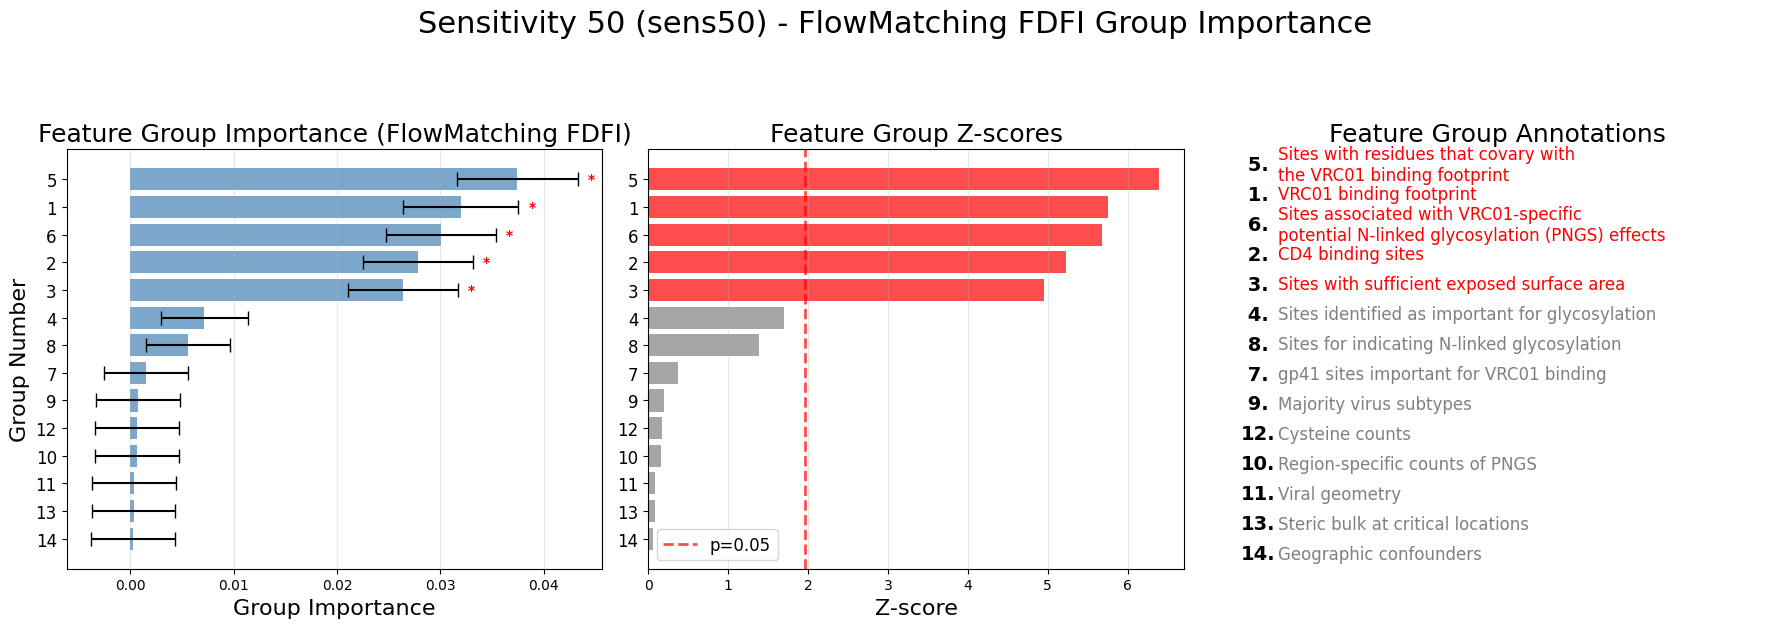

In [13]:
DATASET_LABELS = {
    "sens50": "Sensitivity 50",
    "sens80": "Sensitivity 80",
    "ic50": "IC50 Censored",
}
dataset_label = DATASET_LABELS.get(outcome, outcome)

group_df_sorted = res_df.sort_values("importance", ascending=True).reset_index(drop=True)
group_df_sorted = group_df_sorted.merge(group_mapping, on="group", how="left")

fig, axes = plt.subplots(1, 3, figsize=(18, 6), gridspec_kw={"width_ratios": [3, 3, 3]})
fig.suptitle(
    f"{dataset_label} ({outcome}) - FlowMatching FDFI Group Importance",
    fontsize=22,
    y=1.04,
)

group_numbers = list(group_df_sorted["group_num"])

ax1 = axes[0]
ax1.barh(
    range(len(group_df_sorted)),
    group_df_sorted["importance"],
    xerr=group_df_sorted["se"],
    error_kw=dict(capsize=5),
    alpha=0.7,
    color="steelblue",
)
ax1.set_yticks(range(len(group_df_sorted)))
ax1.set_yticklabels(group_numbers, fontsize=12)
ax1.set_xlabel("Group Importance", fontsize=16)
ax1.set_title("Feature Group Importance (FlowMatching FDFI)", fontsize=18)
ax1.set_ylabel("Group Number", fontsize=16)
ax1.grid(axis="x", alpha=0.3)

for i, (_, row) in enumerate(group_df_sorted.iterrows()):
    if row["reject_null"]:
        ax1.text(
            row["importance"] + row["se"] + 0.001,
            i,
            "*",
            va="center",
            fontweight="bold",
            color="red",
        )

ax2 = axes[1]
colors = ["red" if reject_null else "gray" for reject_null in group_df_sorted["reject_null"]]
ax2.barh(range(len(group_df_sorted)), group_df_sorted["zscore"], alpha=0.7, color=colors)
ax2.set_yticks(range(len(group_df_sorted)))
ax2.set_yticklabels(group_numbers, fontsize=12)
ax2.set_xlabel("Z-score", fontsize=16)
ax2.set_title("Feature Group Z-scores", fontsize=18)
ax2.grid(axis="x", alpha=0.3)
ax2.axvline(x=1.96, color="red", linestyle="--", linewidth=2, alpha=0.7, label="p=0.05")
ax2.legend(fontsize=12)

ax3 = axes[2]
ax3.set_xlim(0, 1)
ax3.set_ylim(-0.5, len(group_df_sorted) - 0.5)

for i, (_, row) in enumerate(group_df_sorted.iterrows()):
    group_name = row["group"]
    display_name = row["description"] if pd.notna(row["description"]) else group_name
    text_color = "red" if row["reject_null"] else "gray"

    ax3.text(
        0.02,
        i,
        f"{int(row['group_num']):2d}.",
        va="center",
        ha="left",
        fontsize=14,
        fontweight="bold",
        color="black",
    )
    ax3.text(
        0.09,
        i,
        display_name,
        va="center",
        ha="left",
        fontsize=12,
        color=text_color,
    )

ax3.set_yticks([])
ax3.set_xticks([])
ax3.set_title("Feature Group Annotations", fontsize=18)
for spine in ax3.spines.values():
    spine.set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
